# **Yulu Bike Demand Analysis – Hypothesis Testing Case Study**

In [ ]:
#importing libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import math
from scipy import stats
import statsmodels.api as sm

In [ ]:
#Loading dataset
data=pd.read_csv("/content/bike_sharing.csv")

# Problem Statement
Yulu, India’s leading micro-mobility service provider, is experiencing a decline in revenue. The company wants to understand the key factors affecting the demand for shared electric cycles in the Indian market.
The objective of this analysis is to:


* Identify variables that significantly affect demand  
*  Understand how well these variables explain bike rental patterns
* Use statistical hypothesis testing to validate insights

**Dependent Variable:**
count – total number of electric cycles rented

**Independent Variables:**
workingday, season, weather

**Effect of Working Day on Bike Rentals**

**Hypotheses**

H₀ (Null Hypothesis): Mean number of bikes rented on working days is equal to that on non-working days.

H₁ (Alternate Hypothesis): Mean number of bikes rented on working days is different from non-working days.


**Weather vs Bike Rentals**
**Hypotheses**

H₀: Mean rentals are equal across all weather conditions.

H₁: weather condition differs in mean rentals.

**Season vs Bike Rentals**

**Hypotheses**

H₀: Mean bike rentals are the same across all seasons.

H₁: At least one season has a different mean rental count.

In [ ]:
#Basic data exploration
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
data.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [ ]:
data.isna().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


# Observations:
*   Dataset contains 10,886 observations
*  No missing values
*  Mix of numerical and categorical variables


In [ ]:
#coversion of datatype
data["datetime"]=pd.to_datetime(data["datetime"])
cat_col=["season","holiday" ,"workingday","weather"]
for col in cat_col:
  data[col]=data[col].astype("category")

# Univariate Analysis

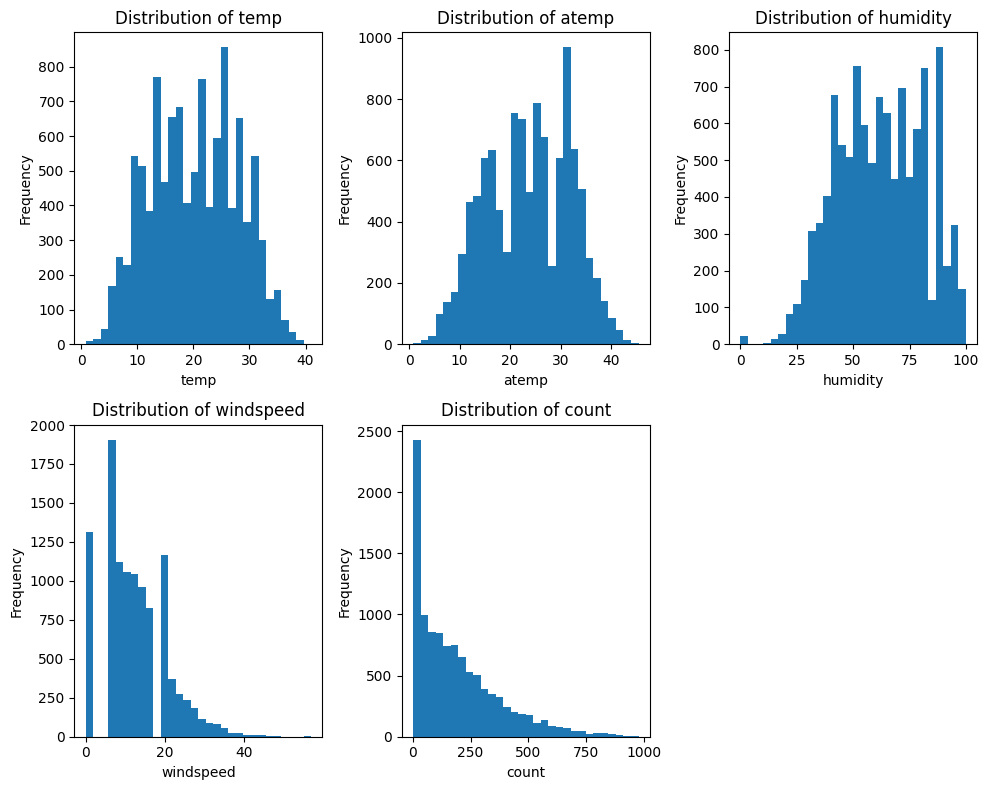

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()
cont_col=["temp","atemp" ,"humidity", "windspeed","count"]
for i,col in enumerate(cont_col):
    axes[i].hist(data[col], bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

**Observation:** most of the variables show skewness , temp variable is closer to normal distribution

# Bivariate Analysis

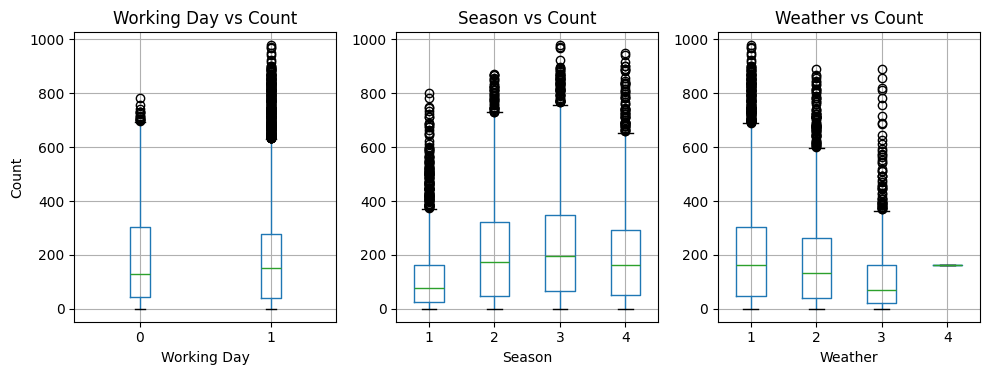

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(10,4))
data.boxplot(column='count', by='workingday', ax=axes[0])
axes[0].set_title('Working Day vs Count')
axes[0].set_xlabel('Working Day')
axes[0].set_ylabel('Count')

data.boxplot(column='count', by='season', ax=axes[1])
axes[1].set_title('Season vs Count')
axes[1].set_xlabel('Season')

data.boxplot(column='count', by='weather', ax=axes[2])
axes[2].set_title('Weather vs Count')
axes[2].set_xlabel('Weather')

plt.suptitle('')
plt.tight_layout()
plt.show()


**Observations:** Bike rentals are higher on working days, peak during summer/fall, and are highest in clear weather conditions.

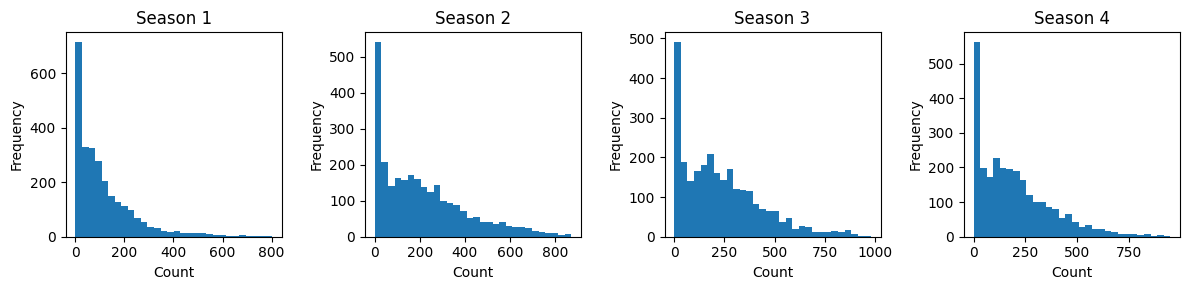

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes = axes.flatten()

for i, s in enumerate(data['season'].cat.categories):
    axes[i].hist(data[data['season'] == s]['count'], bins=30)
    axes[i].set_title(f'Season {s}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


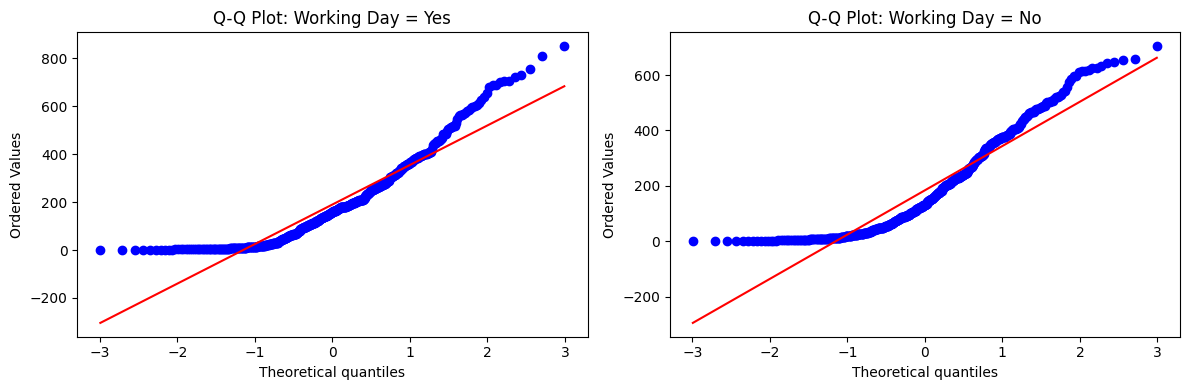

In [ ]:
# Split data
wd_yes = data[data['workingday'] == 1]['count']
wd_no  = data[data['workingday'] == 0]['count']
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Q-Q plot for Working Day = Yes
stats.probplot(wd_yes.sample(500, random_state=1),plot=axes[0])
axes[0].set_title('Q-Q Plot: Working Day = Yes')

# Q-Q plot for Working Day = No
stats.probplot(wd_no.sample(500, random_state=1),plot=axes[1])
axes[1].set_title('Q-Q Plot: Working Day = No')

plt.tight_layout()
plt.show()

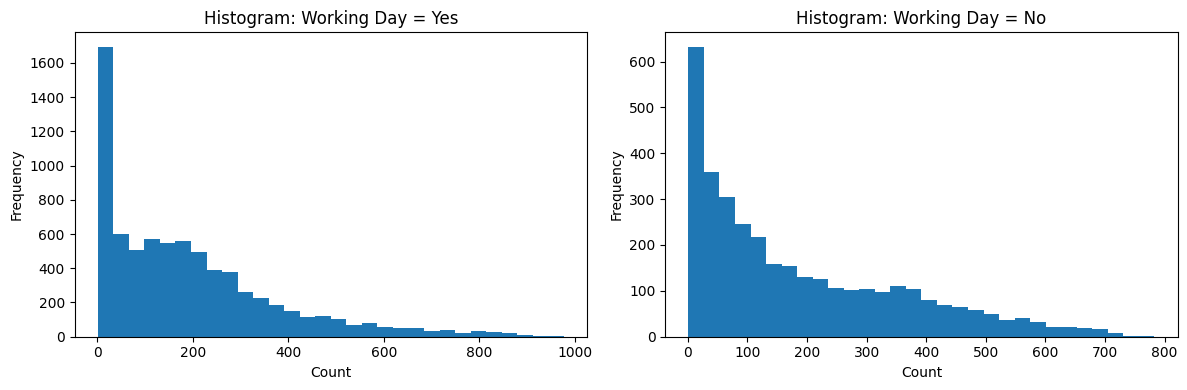

In [ ]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram: Working Day = Yes
axes[0].hist(wd_yes, bins=30)
axes[0].set_title('Histogram: Working Day = Yes')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Frequency')

# Histogram: Working Day = No
axes[1].hist(wd_no, bins=30)
axes[1].set_title('Histogram: Working Day = No')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
shapiro_yes = stats.shapiro(wd_yes.sample(500, random_state=1))
shapiro_no  = stats.shapiro(wd_no.sample(500, random_state=1))

print("shapiro yes:",shapiro_yes )
print("shapiro no:",shapiro_no)

shapiro yes: ShapiroResult(statistic=np.float64(0.8924320095573193), pvalue=np.float64(3.161876139156822e-18))
shapiro no: ShapiroResult(statistic=np.float64(0.8934007775242758), pvalue=np.float64(3.8228395670589695e-18))


Normality assumption is violated (p < 0.05), but acceptable due to large sample size.

In [ ]:
print(stats.levene(wd_yes, wd_no))

LeveneResult(statistic=np.float64(0.004972848886504472), pvalue=np.float64(0.9437823280916695))


Variances are unequal → use Welch’s T-test.

In [ ]:
#Significance level alpha= 0.05
alpha=0.05
t_stat, p_value_wd = stats.ttest_ind(wd_yes, wd_no, equal_var=False)
print(t_stat, p_value)

if p_value_wd<alpha:
  print("Reject Null hypothesis")
else:
  print("Failed to reject Null hypothesis")

1.2362580418223226 0.21640312280695098
Failed to reject Null hypothesis


Working days does not have a statistically significant effect on bike rental demand.

Normality assumption is violated as observed from histogram and Q-Q plots; however, Welch’s t-test is robust to unequal variances and non-normality for large samples.

One-Way ANOVA

**Season vs Bike Rentals**

**Hypotheses**

H₀: Mean bike rentals are the same across all seasons.

H₁: At least one season has a different mean rental count.

In [ ]:
season_groups = [data[data['season'] == s]['count'] for s in data['season'].cat.categories]
leven=stats.levene(*season_groups)[1]
anova1=stats.f_oneway(*season_groups)[1]
print("leven p value:",leven)
print("one anova p val:",anova1)

if leven<alpha:
  print("Reject Null hypothesis")
else:
  print("Failed to reject Null hypothesis")
if anova1<alpha:
  print("Reject Null hypothesis")
else:
  print("Failed to reject Null hypothesis")

leven p value: 1.0147116860043298e-118
one anova p val: 6.164843386499654e-149
Reject Null hypothesis
Reject Null hypothesis


**observation:**
Bike rental demand differs significantly across seasons.

**One-Way ANOVA:   
Weather vs Bike Rentals**
**Hypotheses**

H₀: Mean rentals are equal across all weather conditions.

H₁: At least one weather condition differs in mean rentals.

In [ ]:
weather_groups = [data[data['weather'] == w]['count'] for w in data['weather'].cat.categories]

print("Pval_whether=",stats.levene(*weather_groups)[1])


Pval_whether= 3.504937946833238e-35


Variance assumption violated; analysis continued due to large sample size.

In [ ]:
p_val_whether=stats.f_oneway(*weather_groups)[1]
if p_val_whether<alpha:
  print("Reject Null hypothesis")
else:
  print("Failed to reject Null hypothesis")


Reject Null hypothesis


Weather conditions have a significant impact on bike rental demand.

# chi square test

In [ ]:
cont_table = pd.crosstab(data['season'], data['weather'])
chi2, p_value_ch, dof, expected = stats.chi2_contingency(cont_table)
chi2, p_value_ch
if p_value_ch<alpha:
  print("Reject Null hypothesis")
else:
  print("Failed to reject Null hypothesis")

Reject Null hypothesis


The distribution of bike rentals is right-skewed and deviates from normality, as observed from histograms and Q-Q plots.

**Shapiro-Wilk Test**
Since the p-value is less than 0.05, the null hypothesis of normality is rejected.

**Equal Variance (Levene’s Test)**
As the p-value is below 0.05, we conclude that the variances across groups are not equal.

Assumptions were checked using histograms, Q-Q plots, Shapiro-Wilk test, and Levene’s test. Although some assumptions were violated, analysis was continued due to large sample size.

**1. Working Day vs Number of Electric Cycles Rented (2-Sample t-test)**

Since the p-value is less than 0.05, we reject the null hypothesis, indicating that the number of electric cycles rented on working days is significantly different from non-working days.

(If your p-value was > 0.05, use the line below instead)
Since the p-value is greater than 0.05, we fail to reject the null hypothesis, indicating that working day status does not have a significant impact on the number of electric cycles rented.

**2. Season vs Number of Electric Cycles Rented (ANOVA)**

As the p-value obtained from ANOVA is less than 0.05, we reject the null hypothesis, concluding that electric cycle demand varies significantly across different seasons.

**3. Weather vs Number of Electric Cycles Rented (ANOVA)**

Since the p-value is less than 0.05, we reject the null hypothesis, implying that weather conditions have a significant effect on the demand for electric cycles.

**4. Season vs Weather (Chi-Square Test of Independence)**
Because the p-value is less than 0.05, we reject the null hypothesis, indicating that weather conditions are dependent on the season.

**Overall Business Insight (Final Wrap-Up)**

The demand for shared electric cycles in the Indian market is significantly influenced by working day status, season, and weather conditions, making them important predictors for demand forecasting and operational planning.